# 컨볼루션 신경망
※ 해당 실습은 CNN을 활용한 이진분류 예제입니다.


## Dogs vs cats

- 이미지 데이터 경로 설정

In [1]:
# train 데이터 폴더 정의
train_cats_dir = '/home/dmin/project/data/cats_and_dogs_filtered/train/cats'
train_dogs_dir = '/home/dmin/project/data/cats_and_dogs_filtered/train/dogs'

# validation 데이터 폴더 정의
val_cats_dir = '/home/dmin/project/data/cats_and_dogs_filtered/validation/cats'
val_dogs_dir = '/home/dmin/project/data/cats_and_dogs_filtered/validation/dogs'

- train/validation 데이터 파일 정의

In [2]:
import os

train_cats_fnames = os.listdir(train_cats_dir)
train_dogs_fnames = os.listdir(train_dogs_dir) 

print(train_cats_fnames[:5])
print(train_dogs_fnames[:5])

['cat.580.jpg', 'cat.428.jpg', 'cat.292.jpg', 'cat.679.jpg', 'cat.214.jpg']
['dog.627.jpg', 'dog.193.jpg', 'dog.538.jpg', 'dog.269.jpg', 'dog.750.jpg']


In [3]:
val_cats_fnames = os.listdir(val_cats_dir)
val_dogs_fnames = os.listdir(val_dogs_dir)

print(val_cats_fnames[:5])
print(val_dogs_fnames[:5])

['cat.2051.jpg', 'cat.2229.jpg', 'cat.2215.jpg', 'cat.2160.jpg', 'cat.2139.jpg']
['dog.2292.jpg', 'dog.2408.jpg', 'dog.2062.jpg', 'dog.2192.jpg', 'dog.2313.jpg']


- 학습데이터와 검증데이터 건수 확인

In [4]:
print(f'학습데이터 - cat: {len(train_cats_fnames)}, dog: {len(train_dogs_fnames)}')
print(f'검증데이터 - cat: {len(val_cats_fnames)}, dog: {len(val_dogs_fnames)}')

학습데이터 - cat: 1000, dog: 1000
검증데이터 - cat: 500, dog: 500


- 데이터 시각화

['/home/dmin/project/data/cats_and_dogs_filtered/train/cats/cat.479.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/cats/cat.169.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/cats/cat.513.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/cats/cat.902.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/cats/cat.878.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/cats/cat.990.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/cats/cat.620.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/cats/cat.938.jpg']
['/home/dmin/project/data/cats_and_dogs_filtered/train/dogs/dog.691.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/dogs/dog.621.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/dogs/dog.252.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/dogs/dog.451.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/train/dogs/dog.564.jpg', '/home/dmin/project/data/cats_and_dogs_filtered/t

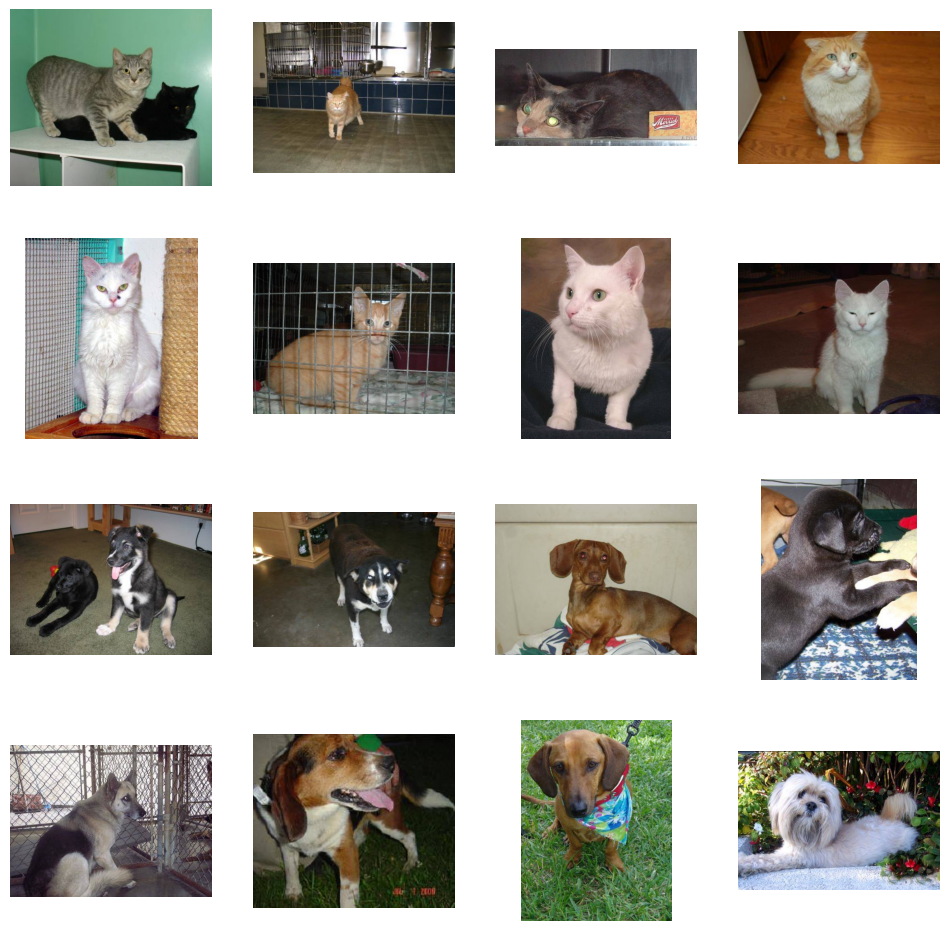

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

nrows, ncols = 4, 4  # 출력 행/열 개수 정의
pic_index = 0

fig = plt.gcf()
fig.set_size_inches(ncols*3, nrows*3)

pic_index += 108 

next_cats_pix = [ os.path.join(train_cats_dir, fname)  
                 for fname in train_cats_fnames[pic_index-8:pic_index]]

next_dogs_pix = [ os.path.join(train_dogs_dir, fname)  
                 for fname in train_dogs_fnames[pic_index-8:pic_index]]

print(next_cats_pix)
print(next_dogs_pix)

for i, img_path in enumerate(next_cats_pix + next_dogs_pix):
    axs = plt.subplot(nrows, ncols, i+1)   # 4행/4열의 이미지 출력
    axs.axis('off')   # 눈금선 제거

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

- 데이터 스케일링

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 이미지 픽셀을 0 ~ 1 사이의 값으로 스케일 조정
img_datagen = ImageDataGenerator(rescale=1./255)

# 이미지 제너레이터 적용
train_generator = img_datagen.flow_from_directory(
    './data/cats_and_dogs_filtered/train/',   # 학습 이미지 저장 폴더
    batch_size=20,                       # 모델에 전달한 이미지 개수(배치크기)
    target_size=(150, 150),              # 이미지 사이즈(리사이즈)
    class_mode='binary'                  # 이진 분류(cat vs dos, 0 또는 1)
    )

validation_generator = img_datagen.flow_from_directory(
    './data/cats_and_dogs_filtered/validation/',   # 학습 이미지 저장 폴더
    batch_size=20,                       # 모델에 전달한 이미지 개수(배치크기)
    target_size=(150, 150),              # 이미지 사이즈(리사이즈)
    class_mode='binary'                  # 이진 분류(cat vs dos, 0 또는 1)
    )

I0000 00:00:1784679214.268722    5122 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784679214.576205    5122 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784679216.209175    5122 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


### 모델 구성
- Conv2D, MaxPool2D

In [7]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Dense, Flatten
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.models import Sequential

In [8]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPool2D((2, 2), padding='same'))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/home/dmin/miniconda3/envs/pytorchedu/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1784679218.979447    5122 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,895,553 (11.05 MB)

 Trainable params: 2,895,553 (11.05 MB)

 Non-trainable params: 0 (0.00 B)

- 컴파일 및 모델 학습하기

In [10]:
# binary_crossentropy: 이진분류
model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(0.0001),
              metrics=['acc'])

In [11]:
# 스템값 계산
def get_step(train_len, batch_size):
    if(train_len % batch_size > 0):
        return train_len // batch_size + 1
    else:
        return train_len // batch_size

In [12]:
history = model.fit(train_generator,                     # 학습 데이터
                    steps_per_epoch=get_step(2000, 32),  # 한 epoch당 베치 반복 횟수
                    epochs=100,                           # 전체 학습 반복 횟수
                    validation_data=validation_generator,# 검증 데이터 
                    validation_steps=50)                 # 검증 데이터 반복 횟수

Epoch 1/100


I0000 00:00:1784679219.889811    5122 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784679220.641411    5433 service.cc:153] XLA service 0x7290cc034200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784679220.641441    5433 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1784679220.671823    5433 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784679220.852247    5433 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1784679220.923606    5433 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1884__.48


 4/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.4750 - loss: 0.8385

I0000 00:00:1784679228.674659    5433 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - acc: 0.5198 - loss: 0.7083 - val_acc: 0.5090 - val_loss: 0.6907
Epoch 2/100
37/63 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.5176 - loss: 0.6940

/home/dmin/miniconda3/envs/pytorchedu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.5176 - loss: 0.6940 - val_acc: 0.5260 - val_loss: 0.6916
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.5341 - loss: 0.6905 - val_acc: 0.5770 - val_loss: 0.6891
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.5473 - loss: 0.6841 - val_acc: 0.5280 - val_loss: 0.6880
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.5810 - loss: 0.6787 - val_acc: 0.6010 - val_loss: 0.6763
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.5730 - loss: 0.6777 - val_acc: 0.6020 - val_loss: 0.6712
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.5802 - loss: 0.6675 - val_acc: 0.6110 - val_loss: 0.6623
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.6068 - loss: 0.6525 - val_acc: 0.6310 - val_loss: 0.6559
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.5802 - loss: 0.6525 - val_acc: 0.6150 - val_loss: 0.6509
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.6230 -

- 학습 과정 그려보기

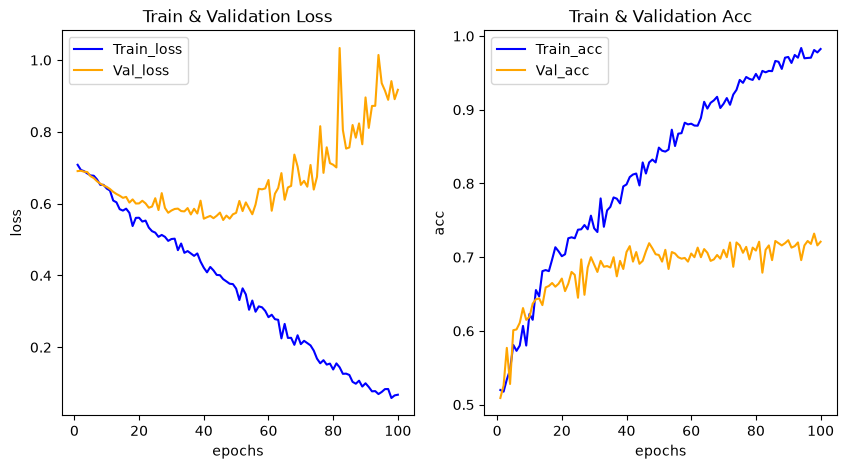

In [13]:
import matplotlib.pyplot as plt
his_data = history.history

loss = his_data['loss']
val_loss = his_data['val_loss']

epochs = range(1, len(loss)+1)

fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실율(lossl)
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color='blue', label='Train_loss')
ax1.plot(epochs, val_loss, color='orange', label='Val_loss')
ax1.set_title('Train & Validation Loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

# 훈련 및 검증 정확도
acc = his_data['acc']
val_acc = his_data['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color='blue', label='Train_acc')
ax2.plot(epochs, val_acc, color='orange', label='Val_acc')
ax2.set_title('Train & Validation Acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

- 학습한 모델 저장

In [14]:
# model.save('./models/cat_dog_model.h5') 
model.save('./models/cat_dog_model.keras') 

#### 모델 테스트

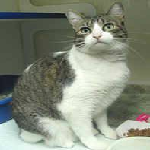

In [15]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img('./data/cats_and_dogs_filtered/validation/cats/cat.2024.jpg',
                     target_size=(150, 150))
img

In [16]:
img_arr = image.img_to_array(img)

print(img_arr)

[[[108. 116.  92.]
  [108. 116.  92.]
  [108. 116.  92.]
  ...
  [102. 106.  83.]
  [110. 114.  91.]
  [112. 116.  93.]]

 [[108. 116.  92.]
  [108. 116.  92.]
  [108. 116.  92.]
  ...
  [106. 110.  87.]
  [114. 118.  95.]
  [117. 121.  98.]]

 [[108. 116.  92.]
  [108. 116.  92.]
  [108. 116.  92.]
  ...
  [108. 112.  89.]
  [118. 122.  99.]
  [121. 125. 102.]]

 ...

 [[218. 240. 238.]
  [218. 240. 238.]
  [220. 242. 240.]
  ...
  [209. 225. 198.]
  [209. 225. 198.]
  [209. 225. 198.]]

 [[218. 240. 238.]
  [218. 240. 238.]
  [220. 242. 240.]
  ...
  [209. 225. 198.]
  [209. 225. 198.]
  [209. 225. 198.]]

 [[218. 240. 238.]
  [218. 240. 238.]
  [220. 242. 240.]
  ...
  [209. 225. 198.]
  [209. 225. 198.]
  [209. 225. 198.]]]


In [17]:
# 학습시 사용한 데이터 차원과 동일하게 변경(2000, 150, 150, 3)
# 3차원(150, 150, 3) => 4차원 변경((1. 150, 150, 3))
print(f'변경전:{img_arr.shape}')
img_arr_dims = np.expand_dims(img_arr, axis=0)
print(f'변경후:{img_arr_dims.shape}')

변경전:(150, 150, 3)
변경후:(1, 150, 150, 3)


In [18]:
pred = model.predict(img_arr_dims)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step


array([[0.]], dtype=float32)

#### 서비스를 위한 함수 생성 및 Cat & Dog 분류

In [19]:
from tensorflow.keras.preprocessing import image   # 이미지 처리
from tensorflow.keras.models import load_model     # 모델 읽어오기
import numpy as np
import matplotlib.pyplot as plt

In [20]:
model = load_model('./models/cat_dog_model.keras')

In [21]:
# 서비스 함수 생성
def pred(filename):
    # 이미지 읽어오기
    input_img = image.load_img(filename, target_size=(150, 150))
    plt.imshow(input_img)

    # 이미지 차원 변경
    img_arr = image.img_to_array(input_img)
    images = np.expand_dims(img_arr, axis=0)

    classification = model.predict(images)
    print(classification[0])

    if classification[0][0] > 0:
        print(filename.split('/')[-1] + '은 강아지 사진입니다.')
    else:
        print(filename.split('/')[-1] + '은 고양이 사진입니다.')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
[1.]
dog.14.jpg은 강아지 사진입니다.


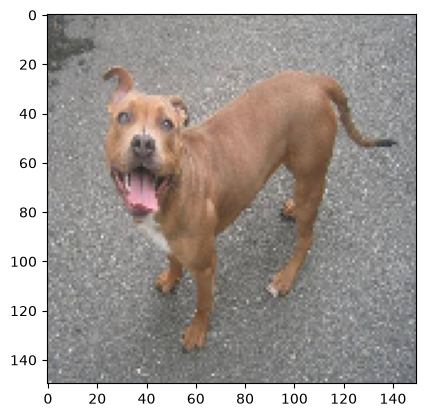

In [22]:
pred('./data/cats_and_dogs_filtered/train/dogs/dog.14.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[0.]
cat1.png은 고양이 사진입니다.


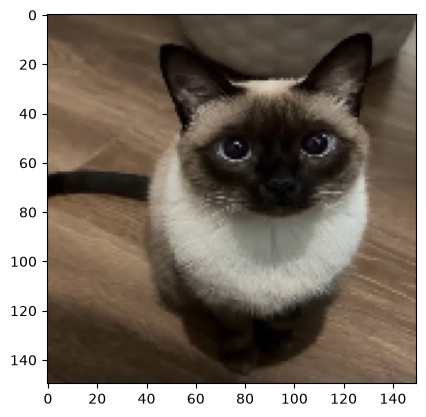

In [23]:
pred('./images/cat1.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[1.]
image.png은 강아지 사진입니다.


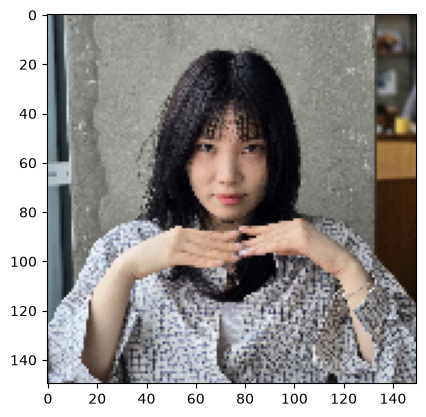

In [25]:
pred('./images/image.png')